# ***Student Name: Tushar Panchal***

# ***En. No. : 21162101014***

# ***Branch: CBA***

# ***Batch:  71***

# ***Subject: ML (Machine Learning)***

# **EXPERIMENT 9**
<hr>

###Select dataset of your choice for image processing (i.e. object detection, emotion detection, plant leaf detection, etc.) and apply CNN to the chosen dataset. (sample code for CNN attached)
<hr>

_(Database used : https://www.kaggle.com/datasets/alxmamaev/flowers-recognition)_


In [ ]:
import kagglehub

path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files : ", path)

100%|██████████| 225M/225M [00:02<00:00, 86.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127801 (\N{ROSE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127799 (\N{TULIP}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127803 (\N{SUNFLOWER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127804 (\N{BLOSSOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


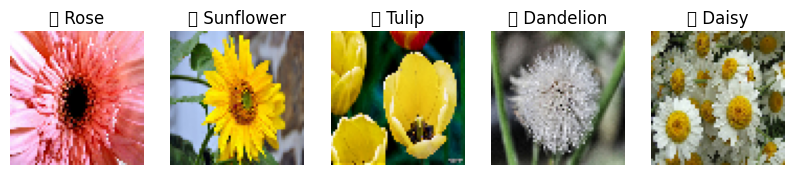

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Path to the flowers dataset
dataset_path = '/root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers/'

# List class names (folders inside flowers/)
original_class_names = os.listdir(dataset_path)

# Add emojis to class names
emoji_map = {
    'daisy': '🌼 Daisy',
    'dandelion': '🌻 Dandelion',
    'rose': '🌹 Rose',
    'sunflower': '🌞 Sunflower',
    'tulip': '🌷 Tulip'
}
class_names = [emoji_map[class_name] for class_name in original_class_names]

# Initialize lists to hold image data and labels
image_data = []
labels = []

# Load images and their corresponding labels
for label, class_name in enumerate(original_class_names):  # Use original class names for folder paths
    class_folder = os.path.join(dataset_path, class_name)
    img_files = os.listdir(class_folder)

    for img_file in img_files:
        img_path = os.path.join(class_folder, img_file)

        # Load and resize images to a fixed size (64x64)
        img = image.load_img(img_path, target_size=(64, 64))
        img_array = image.img_to_array(img)

        image_data.append(img_array)
        labels.append(label)

# Convert lists to numpy arrays
image_data = np.array(image_data)
labels = np.array(labels)

# Normalize the image data
image_data = image_data / 255.0

# Convert labels to one-hot encoding
labels = to_categorical(labels, num_classes=len(class_names))

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(image_data, labels, test_size=0.2, random_state=42)

# Display some images from the dataset to verify
plt.figure(figsize=(10, 10))
for i, (class_name, original_class_name) in enumerate(zip(class_names[:5], original_class_names[:5])):
    class_folder = os.path.join(dataset_path, original_class_name)
    img_file = os.listdir(class_folder)[0]  # Get the first image from each class folder
    img_path = os.path.join(class_folder, img_file)

    # Load image and convert to array
    img = image.load_img(img_path, target_size=(64, 64))

    plt.subplot(1, 5, i+1)  # Display 5 images in a row
    plt.imshow(img)
    plt.title(class_name)  # Display emoji-enhanced class names
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Build the CNN model
model = Sequential()

# Add Convolutional and Pooling Layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

# Flatten the data for the Dense layers
model.add(Flatten())

# Add Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dense(len(class_names), activation='softmax'))  # Output layer with softmax for multi-class classification

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,625,797 (6.20 MB)

 Trainable params: 1,625,797 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


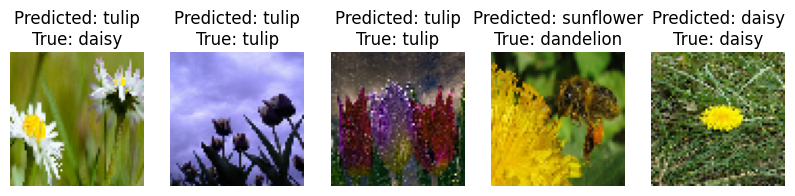


108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - accuracy: 0.9981 - loss: 0.0122 - val_accuracy: 0.6748 - val_loss: 1.7936
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


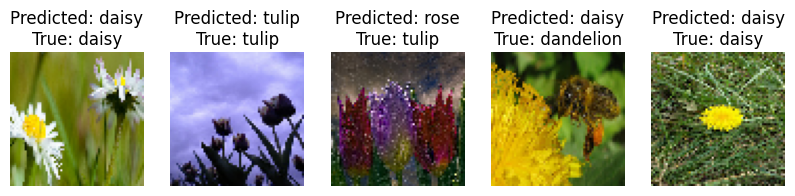


108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 179ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.6319 - val_loss: 1.7232
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


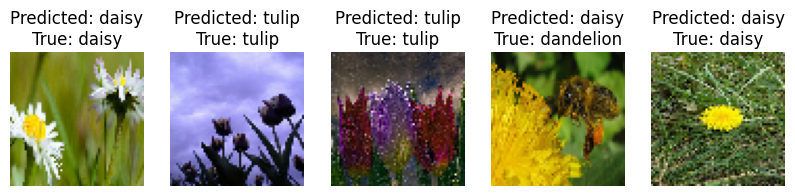


108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 189ms/step - accuracy: 0.9691 - loss: 0.1002 - val_accuracy: 0.6354 - val_loss: 1.6049
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


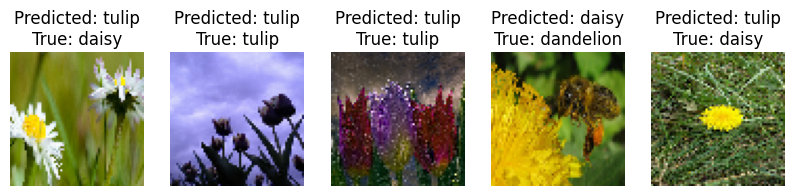


108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 190ms/step - accuracy: 0.9886 - loss: 0.0419 - val_accuracy: 0.6701 - val_loss: 1.8100
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


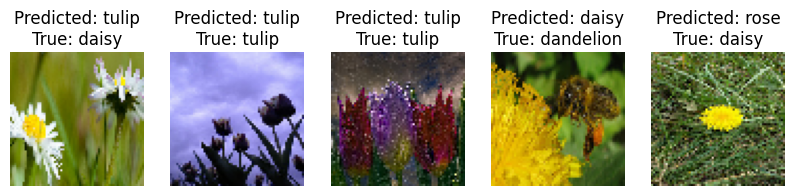


108/108 ━━━━━━━━━━━━━━━━━━━━ 29s 272ms/step - accuracy: 0.9942 - loss: 0.0193 - val_accuracy: 0.6505 - val_loss: 1.8331
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


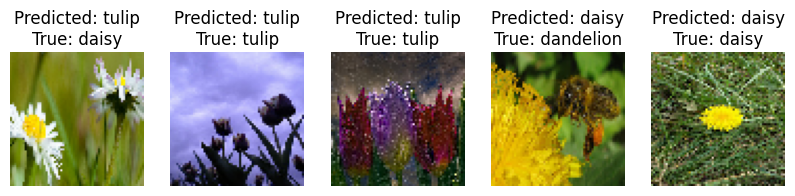


108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 187ms/step - accuracy: 0.9993 - loss: 0.0075 - val_accuracy: 0.6667 - val_loss: 1.9462
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


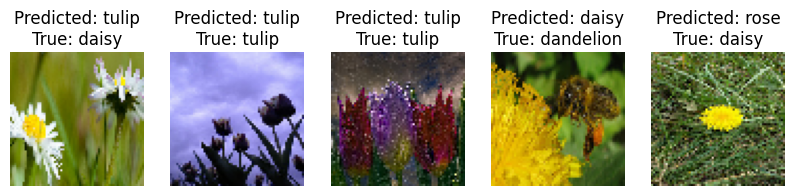


108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.9998 - loss: 0.0031 - val_accuracy: 0.6690 - val_loss: 2.0322
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


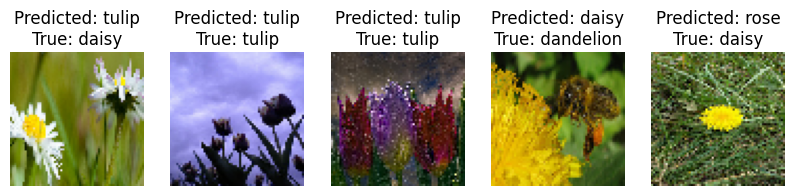


108/108 ━━━━━━━━━━━━━━━━━━━━ 23s 208ms/step - accuracy: 0.9995 - loss: 0.0036 - val_accuracy: 0.6759 - val_loss: 1.9862
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


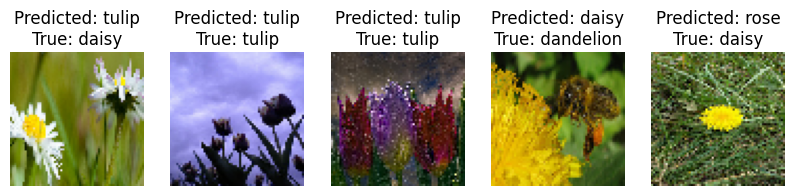


108/108 ━━━━━━━━━━━━━━━━━━━━ 40s 203ms/step - accuracy: 0.9998 - loss: 0.0025 - val_accuracy: 0.6701 - val_loss: 1.9758
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


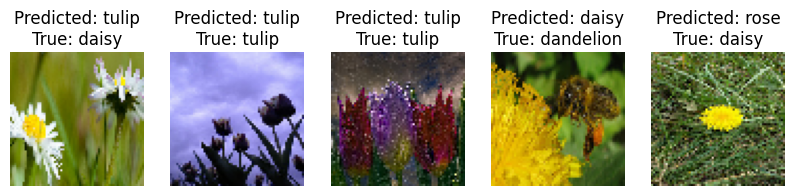


108/108 ━━━━━━━━━━━━━━━━━━━━ 23s 213ms/step - accuracy: 0.9993 - loss: 0.0052 - val_accuracy: 0.6667 - val_loss: 2.0014


In [ ]:
from tensorflow.keras.callbacks import LambdaCallback
import matplotlib.pyplot as plt
import numpy as np

# Callback to visualize predictions during training
def visualize_predictions(epoch, logs):
    # Get some test images and their true labels
    test_images = x_test[:5]
    true_labels = np.argmax(y_test[:5], axis=1)

    # Predict using the trained model
    predictions = model.predict(test_images)
    predicted_labels = np.argmax(predictions, axis=1)

    # Display the images and the predictions
    plt.figure(figsize=(10, 10))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(test_images[i])
        plt.title(f"Predicted: {class_names[predicted_labels[i]]}\nTrue: {class_names[true_labels[i]]}")
        plt.axis('off')
    plt.show()
    print()

# Add the callback to the training
visualize_callback = LambdaCallback(on_epoch_end=visualize_predictions)

# Train the model with the visualization callback
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), callbacks=[visualize_callback])

In [ ]:
from sklearn.metrics import classification_report
from tabulate import tabulate

# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Generate classification report
report = classification_report(y_test_classes, y_pred_classes, target_names=class_names, output_dict=True)

# Prepare data for the table
table_data = []
for flower, metrics in report.items():
    if flower not in ["accuracy", "macro avg", "weighted avg"]:  # Skip overall metrics for now
        table_data.append([flower, f"{metrics['precision']:.2f}", f"{metrics['recall']:.2f}", f"{metrics['f1-score']:.2f}", metrics["support"]])

# Add a divider for overall metrics
table_data.append(["-" * 12, "-" * 9, "-" * 9, "-" * 10, "-" * 8])
table_data.append(["Accuracy", "-", "-", f"{report['accuracy']:.2f}", len(y_test_classes)])
table_data.append(["Macro Avg", f"{report['macro avg']['precision']:.2f}", f"{report['macro avg']['recall']:.2f}", f"{report['macro avg']['f1-score']:.2f}", report['macro avg']["support"]])
table_data.append(["Weighted Avg", f"{report['weighted avg']['precision']:.2f}", f"{report['weighted avg']['recall']:.2f}", f"{report['weighted avg']['f1-score']:.2f}", report['weighted avg']["support"]])

print("\n" + "-" * 100 + "\nClassification Report : \n" + "-" * 100)
print(tabulate(
    table_data,
    headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
    tablefmt="fancy_grid"
))
print("\n" + "-" * 100)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step

----------------------------------------------------------------------------------------------------
Classification Report : 
----------------------------------------------------------------------------------------------------
╒══════════════╤═════════════╤═══════════╤════════════╤═══════════╕
│ Class        │ Precision   │ Recall    │ F1-Score   │ Support   │
╞══════════════╪═════════════╪═══════════╪════════════╪═══════════╡
│ 🌹 Rose      │ 0.61        │ 0.63      │ 0.62       │ 165.0     │
├──────────────┼─────────────┼───────────┼────────────┼───────────┤
│ 🌞 Sunflower │ 0.80        │ 0.66      │ 0.72       │ 158.0     │
├──────────────┼─────────────┼───────────┼────────────┼───────────┤
│ 🌷 Tulip     │ 0.66        │ 0.62      │ 0.63       │ 195.0     │
├──────────────┼─────────────┼───────────┼────────────┼───────────┤
│ 🌻 Dandelion │ 0.63        │ 0.78      │ 0.70       │ 195.0     │
├──────────────┼─────────────┼───────────┼────────────┼─

**Conclusion : CNN can help improve acccuracy over each epoch and can be trained well for future predictions, like image processing and identification**